In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [2]:
spark = SparkSession.builder\
    .appName("nlp")\
    .master("spark://spark-master:7077")\
    .getOrCreate()

spark.sparkContext.setLogLevel("OFF")

spark

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/09/10 23:57:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
df = spark.read.csv("s3a://bronze/imdb_npl", escape="\"",header=True, inferSchema=True)

In [4]:
df.show(5)
print(df.count(), "\n")
df.printSchema()

+---+--------------------+--------------------+---------+
| id|             text_en|             text_pt|sentiment|
+---+--------------------+--------------------+---------+
|  1|Once again Mr. Co...|Mais uma vez, o S...|      neg|
|  2|This is an exampl...|Este é um exemplo...|      neg|
|  3|First of all I ha...|Primeiro de tudo ...|      neg|
|  4|Not even the Beat...|Nem mesmo os Beat...|      neg|
|  5|Brass pictures mo...|Filmes de fotos d...|      neg|
+---+--------------------+--------------------+---------+
only showing top 5 rows



[Stage 3:==>                                                      (1 + 23) / 24]

49459 

root
 |-- id: integer (nullable = true)
 |-- text_en: string (nullable = true)
 |-- text_pt: string (nullable = true)
 |-- sentiment: string (nullable = true)



In [5]:
df.groupBy("sentiment")\
    .agg(F.count(df.id))\
    .show()

[Stage 6:====>                                                    (2 + 22) / 24]

+---------+---------+
|sentiment|count(id)|
+---------+---------+
|      neg|    24765|
|      pos|    24694|
+---------+---------+



In [6]:
df.filter(df.sentiment == "neg").select("text_en").show(1, truncate=False)
df.filter(df.sentiment == "pos").select("text_en").show(1, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|text_en                                                                                            

[Stage 12:=========================================>              (14 + 5) / 19]

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|text_en                                                                                                                                                                                                      

# Bag of Words e Tokenização

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [8]:
sample = df.select("text_en").sample(fraction = 0.1, seed=101)
listsample = [texto['text_en'] for texto in sample.collect()]

In [9]:
wordcloud = WordCloud(
    collocations = False,
    background_color = 'white',
    prefer_horizontal = 1,
    width = 1000,
    height = 600
)
wc_sample = wordcloud.generate(str(listsample))

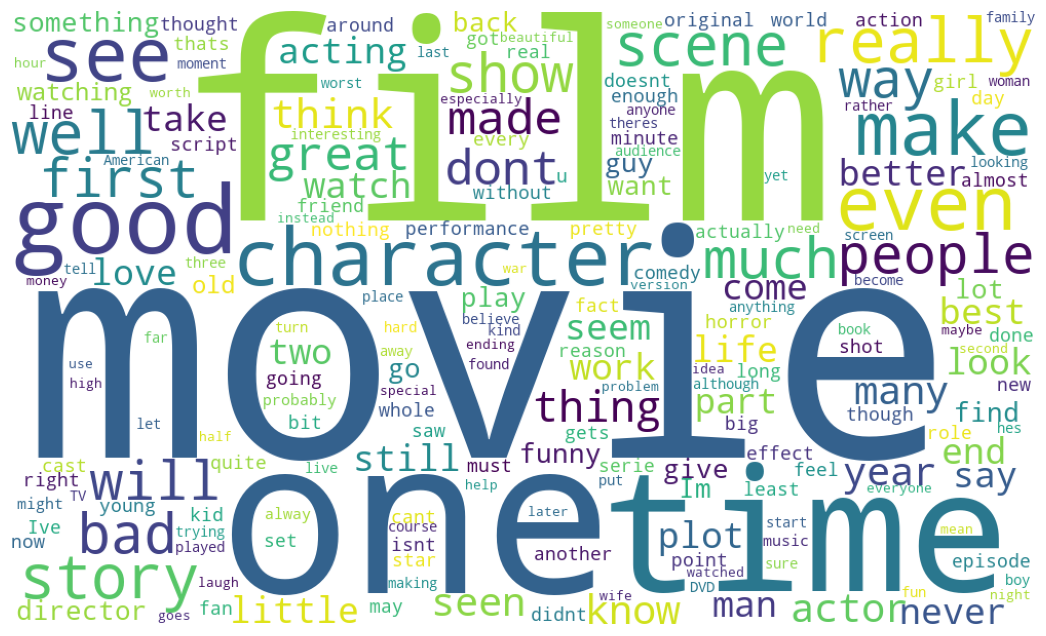

In [10]:
plt.figure(figsize=(20,8))
plt.axis('off')
plt.imshow(wc_sample)

In [11]:
import string
import re

In [12]:
df_treated = df

In [13]:
regex_pattern = f"[{re.escape(string.punctuation)}]"

df_treated = (
    df.withColumn("textoen_regex", F.regexp_replace("text_en", regex_pattern, ""))
      .withColumn("textoen_regex", F.trim(F.col("textoen_regex")))
)

In [14]:
df_treated.show(5)

+---+--------------------+--------------------+---------+--------------------+
| id|             text_en|             text_pt|sentiment|       textoen_regex|
+---+--------------------+--------------------+---------+--------------------+
|  1|Once again Mr. Co...|Mais uma vez, o S...|      neg|Once again Mr Cos...|
|  2|This is an exampl...|Este é um exemplo...|      neg|This is an exampl...|
|  3|First of all I ha...|Primeiro de tudo ...|      neg|First of all I ha...|
|  4|Not even the Beat...|Nem mesmo os Beat...|      neg|Not even the Beat...|
|  5|Brass pictures mo...|Filmes de fotos d...|      neg|Brass pictures mo...|
+---+--------------------+--------------------+---------+--------------------+
only showing top 5 rows



In [15]:
from pyspark.ml.feature import Tokenizer

In [16]:
tokenizer = Tokenizer(inputCol="textoen_regex", outputCol="texten_token")
tokens = tokenizer.transform(df_treated)

In [17]:
tokens.select("texten_token").show(5, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [18]:
import nltk

In [19]:
nltk.download("stopwords")
from nltk.corpus import stopwords
stop_A = stopwords.words("english")

[nltk_data] Downloading package stopwords to /nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
from pyspark.ml.feature import StopWordsRemover
stop_B = StopWordsRemover.loadDefaultStopWords("english")

In [21]:
remover = StopWordsRemover(inputCol="texten_token", outputCol="final")
df_final = remover.transform(tokens)

In [22]:
df_final.show()

+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+
| id|             text_en|             text_pt|sentiment|       textoen_regex|        texten_token|               final|
+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+
|  1|Once again Mr. Co...|Mais uma vez, o S...|      neg|Once again Mr Cos...|[once, again, mr,...|[mr, costner, dra...|
|  2|This is an exampl...|Este é um exemplo...|      neg|This is an exampl...|[this, is, an, ex...|[example, majorit...|
|  3|First of all I ha...|Primeiro de tudo ...|      neg|First of all I ha...|[first, of, all, ...|[first, hate, mor...|
|  4|Not even the Beat...|Nem mesmo os Beat...|      neg|Not even the Beat...|[not, even, the, ...|[even, beatles, w...|
|  5|Brass pictures mo...|Filmes de fotos d...|      neg|Brass pictures mo...|[brass, pictures,...|[brass, pictures,...|
|  6|A funny thing hap...|Uma co

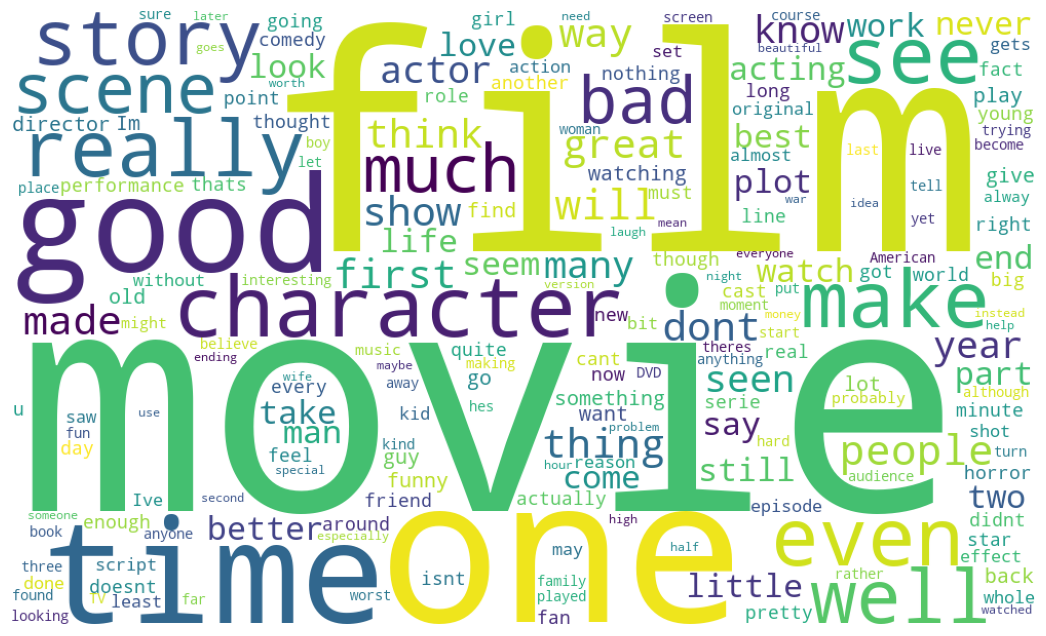

In [23]:
sample = df_final.select("final").sample(fraction = 0.1, seed=101)
wc_sample = wordcloud.generate(str(listsample))
plt.figure(figsize=(20,8))
plt.axis('off')
plt.imshow(wc_sample)

In [24]:
from pyspark.ml.feature import CountVectorizer

In [25]:
#Bag of Words
cv = CountVectorizer(inputCol="final", outputCol="CountVec")
model = cv.fit(df_final)
df_cv = model.transform(df_final)

In [26]:
df_cv.show()

+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+
| id|             text_en|             text_pt|sentiment|       textoen_regex|        texten_token|               final|            CountVec|
+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+
|  1|Once again Mr. Co...|Mais uma vez, o S...|      neg|Once again Mr Cos...|[once, again, mr,...|[mr, costner, dra...|(216507,[0,7,8,11...|
|  2|This is an exampl...|Este é um exemplo...|      neg|This is an exampl...|[this, is, an, ex...|[example, majorit...|(216507,[1,2,3,8,...|
|  3|First of all I ha...|Primeiro de tudo ...|      neg|First of all I ha...|[first, of, all, ...|[first, hate, mor...|(216507,[0,2,4,11...|
|  4|Not even the Beat...|Nem mesmo os Beat...|      neg|Not even the Beat...|[not, even, the, ...|[even, beatles, w...|(216507,[0,1,2,4,...|
|  5|B

In [27]:
from pyspark.ml.feature import HashingTF

In [28]:
#HashingTF
hashingTF = HashingTF(inputCol="final", outputCol="HashingTF")
hashingTF.setNumFeatures(50)
df_htf = hashingTF.transform(df_cv)

In [29]:
df_htf.show()

+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+--------------------+
| id|             text_en|             text_pt|sentiment|       textoen_regex|        texten_token|               final|            CountVec|           HashingTF|
+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+--------------------+
|  1|Once again Mr. Co...|Mais uma vez, o S...|      neg|Once again Mr Cos...|[once, again, mr,...|[mr, costner, dra...|(216507,[0,7,8,11...|(50,[0,5,6,7,8,10...|
|  2|This is an exampl...|Este é um exemplo...|      neg|This is an exampl...|[this, is, an, ex...|[example, majorit...|(216507,[1,2,3,8,...|(50,[0,1,2,3,4,5,...|
|  3|First of all I ha...|Primeiro de tudo ...|      neg|First of all I ha...|[first, of, all, ...|[first, hate, mor...|(216507,[0,2,4,11...|(50,[0,1,2,3,5,6,...|
|  4|Not even the Beat

In [30]:
#TF IDF
from pyspark.ml.feature import IDF
idf = IDF(inputCol="HashingTF", outputCol="IDF")
idfModel = idf.fit(df_htf)
df_idf = idfModel.transform(df_htf)

In [31]:
df_idf.show()

+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
| id|             text_en|             text_pt|sentiment|       textoen_regex|        texten_token|               final|            CountVec|           HashingTF|                 IDF|
+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|  1|Once again Mr. Co...|Mais uma vez, o S...|      neg|Once again Mr Cos...|[once, again, mr,...|[mr, costner, dra...|(216507,[0,7,8,11...|(50,[0,5,6,7,8,10...|(50,[0,5,6,7,8,10...|
|  2|This is an exampl...|Este é um exemplo...|      neg|This is an exampl...|[this, is, an, ex...|[example, majorit...|(216507,[1,2,3,8,...|(50,[0,1,2,3,4,5,...|(50,[0,1,2,3,4,5,...|
|  3|First of all I ha...|Primeiro de tudo ...|      neg|First of all I ha...|[f

In [32]:
from pyspark.ml.feature import StringIndexer

In [33]:
stringindexer = StringIndexer(inputCol="sentiment", outputCol="label")
tokens = stringindexer.fit(tokens).transform(tokens)

In [34]:
tokens.groupBy("sentiment","label")\
    .agg(F.count(df.id))\
    .show()

[Stage 29:==>                                                     (1 + 23) / 24]

+---------+-----+---------+
|sentiment|label|count(id)|
+---------+-----+---------+
|      neg|  0.0|    24765|
|      pos|  1.0|    24694|
+---------+-----+---------+



In [35]:
tokens.show()

+---+--------------------+--------------------+---------+--------------------+--------------------+-----+
| id|             text_en|             text_pt|sentiment|       textoen_regex|        texten_token|label|
+---+--------------------+--------------------+---------+--------------------+--------------------+-----+
|  1|Once again Mr. Co...|Mais uma vez, o S...|      neg|Once again Mr Cos...|[once, again, mr,...|  0.0|
|  2|This is an exampl...|Este é um exemplo...|      neg|This is an exampl...|[this, is, an, ex...|  0.0|
|  3|First of all I ha...|Primeiro de tudo ...|      neg|First of all I ha...|[first, of, all, ...|  0.0|
|  4|Not even the Beat...|Nem mesmo os Beat...|      neg|Not even the Beat...|[not, even, the, ...|  0.0|
|  5|Brass pictures mo...|Filmes de fotos d...|      neg|Brass pictures mo...|[brass, pictures,...|  0.0|
|  6|A funny thing hap...|Uma coisa engraça...|      neg|A funny thing hap...|[a, funny, thing,...|  0.0|
|  7|This German horro...|Este filme de ter...

In [36]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

In [37]:
tokenizer = Tokenizer(inputCol = "textoen_regex", outputCol = "texten_token")
stopwords = StopWordsRemover(inputCol="texten_token", outputCol="textoen_final")
hashingTF = HashingTF(inputCol=stopwords.getOutputCol(), outputCol="HTF", numFeatures=1000)
tfidf = IDF(inputCol="HTF", outputCol="features")
stringindexer = StringIndexer(inputCol="sentiment", outputCol="label")

pipeline = Pipeline(stages = [tokenizer, stopwords, hashingTF, tfidf, stringindexer])

# Machine Learning

In [38]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [39]:
seed= 101

model_woml = pipeline.fit(df_treated)
df_pipeline = model_woml.transform(df_treated)

treino, teste = df_pipeline.randomSplit([0.7, 0.3], seed=seed)

dtc = DecisionTreeClassifier(featuresCol="features", labelCol='label', seed=101, maxDepth=10)
# Train Decision Tree
dtc_model = dtc.fit(treino)

In [40]:
prev_dtc_teste = dtc_model.transform(teste)
prev_dtc_treino = dtc_model.transform(treino)

In [41]:
prev_dtc_treino.show()

+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+--------------------+-----+---------------+--------------------+----------+
| id|             text_en|             text_pt|sentiment|       textoen_regex|        texten_token|       textoen_final|                 HTF|            features|label|  rawPrediction|         probability|prediction|
+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+--------------------+-----+---------------+--------------------+----------+
|  1|Once again Mr. Co...|Mais uma vez, o S...|      neg|Once again Mr Cos...|[once, again, mr,...|[mr, costner, dra...|(1000,[10,21,34,4...|(1000,[10,21,34,4...|  0.0|  [114.0,617.0]|[0.15595075239398...|       1.0|
|  2|This is an exampl...|Este é um exemplo...|      neg|This is an exampl...|[this, is, an, ex...|[example, majorit...|(1000,[0,3,1

In [42]:
def calcula_mostra_matriz_confusao(tipo ,df_transform_modelo, normalize=False, percentage=True):
    tp = df_transform_modelo.where((F.col('label') == 1) & (F.col('prediction') == 1)).count()
    tn = df_transform_modelo.where((F.col('label') == 0) & (F.col('prediction') == 0)).count()
    fp = df_transform_modelo.where((F.col('label') == 0) & (F.col('prediction') == 1)).count()
    fn = df_transform_modelo.where((F.col('label') == 1) & (F.col('prediction') == 0)).count()
    
    valorP = tp + fn if normalize else 1
    valorN = fp + tn if normalize else 1
    
    if percentage and normalize:
        valorP /= 100
        valorN /= 100
    
    tp_val = int(tp / valorP)
    fn_val = int(fn / valorP)
    fp_val = int(fp / valorN)
    tn_val = int(tn / valorN)
    
    print(f"\nMatriz de Confusão - {tipo}")
    print("                 Predito")
    print("           |  Positive |  Negative  |")
    print("-----------*-----------*------------*")
    print(f" Positive  |{tp_val:^9}  |{fn_val:^11} |")
    print("-----------*-----------*------------*")
    print(f" Negative  |{fp_val:^9}  |{tn_val:^11} |")
    print("-----------*-----------*------------*")

In [43]:
calcula_mostra_matriz_confusao("Teste",prev_dtc_teste, normalize=False)
calcula_mostra_matriz_confusao("Treino",prev_dtc_treino, normalize=False)


Matriz de Confusão - Teste
                 Predito
           |  Positive |  Negative  |
-----------*-----------*------------*
 Positive  |  5476     |   1928     |
-----------*-----------*------------*
 Negative  |  3016     |   4617     |
-----------*-----------*------------*


[Stage 84:============================================>           (19 + 5) / 24]


Matriz de Confusão - Treino
                 Predito
           |  Positive |  Negative  |
-----------*-----------*------------*
 Positive  |  14045    |   3245     |
-----------*-----------*------------*
 Negative  |  5848     |   11284    |
-----------*-----------*------------*


In [44]:
evaluator = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
acuracia_treino = evaluator.evaluate(prev_dtc_treino)
acuracia_teste = evaluator.evaluate(prev_dtc_teste)

print(acuracia_treino)
print(acuracia_teste)

[Stage 89:==>                                                     (1 + 23) / 24]

0.7358375457556214
0.671211012835007


# Teste

In [45]:
nova_base = spark.createDataFrame([
        (1, "This is without doubt the worst movie i have ever seen, I hated the acting of the actor."),
        (0, "I loved the movie, excellent acting!"),
    ], ["id", "textoen_regex"])


nova_base = model_woml.transform(nova_base)
prev_dtc_nova_base = dtc_model.transform(nova_base)

In [46]:
prev_dtc_nova_base.show()

+---+--------------------+--------------------+--------------------+--------------------+--------------------+-------------+--------------------+----------+
| id|       textoen_regex|        texten_token|       textoen_final|                 HTF|            features|rawPrediction|         probability|prediction|
+---+--------------------+--------------------+--------------------+--------------------+--------------------+-------------+--------------------+----------+
|  1|This is without d...|[this, is, withou...|[without, doubt, ...|(1000,[35,43,269,...|(1000,[35,43,269,...| [565.0,74.0]|[0.88419405320813...|       0.0|
|  0|I loved the movie...|[i, loved, the, m...|[loved, movie,, e...|(1000,[185,543,73...|(1000,[185,543,73...|[153.0,651.0]|[0.19029850746268...|       1.0|
+---+--------------------+--------------------+--------------------+--------------------+--------------------+-------------+--------------------+----------+



In [47]:
#RandomForest
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

In [48]:
rfc = RandomForestClassifier(seed=seed)

grid = ParamGridBuilder()\
        .addGrid(rfc.maxDepth, [2, 5, 10])\
        .addGrid(rfc.maxBins, [10, 32, 45])\
        .addGrid(rfc.numTrees, [10, 20])\
        .build()

evaluator = MulticlassClassificationEvaluator()

rfc_cv = CrossValidator(
    estimator=rfc,
    estimatorParamMaps=grid,
    evaluator=evaluator,
    numFolds=3,
    seed=seed
)

In [49]:
modelo_rfc_cv = rfc_cv.fit(treino)

In [50]:
prev_rfc_teste = modelo_rfc_cv.transform(teste)
prev_rfc_treino = modelo_rfc_cv.transform(treino)

In [51]:
calcula_mostra_matriz_confusao("Teste",prev_rfc_teste, normalize=False)
calcula_mostra_matriz_confusao("Treino",prev_rfc_treino, normalize=False)


Matriz de Confusão - Teste
                 Predito
           |  Positive |  Negative  |
-----------*-----------*------------*
 Positive  |  5634     |   1770     |
-----------*-----------*------------*
 Negative  |  2308     |   5325     |
-----------*-----------*------------*


[Stage 1115:===============>                                      (7 + 17) / 24]


Matriz de Confusão - Treino
                 Predito
           |  Positive |  Negative  |
-----------*-----------*------------*
 Positive  |  14574    |   2716     |
-----------*-----------*------------*
 Negative  |  4112     |   13020    |
-----------*-----------*------------*


In [52]:
evaluator = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
acuracia_treino = evaluator.evaluate(prev_rfc_treino)
acuracia_teste = evaluator.evaluate(prev_rfc_teste)

print(acuracia_treino)
print(acuracia_teste)

[Stage 1120:==========================>                          (12 + 12) / 24]

0.8016384870141189
0.7288022876903638


In [53]:
prev_rfc_teste.show()

+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+--------------------+-----+--------------------+--------------------+----------+
| id|             text_en|             text_pt|sentiment|       textoen_regex|        texten_token|       textoen_final|                 HTF|            features|label|       rawPrediction|         probability|prediction|
+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+--------------------+-----+--------------------+--------------------+----------+
|  5|Brass pictures mo...|Filmes de fotos d...|      neg|Brass pictures mo...|[brass, pictures,...|[brass, pictures,...|(1000,[3,6,7,11,3...|(1000,[3,6,7,11,3...|  0.0|[6.95699286092124...|[0.34784964304606...|       1.0|
|  6|A funny thing hap...|Uma coisa engraça...|      neg|A funny thing hap...|[a, funny, thing,...|[funny, thing